# **SPECTRA-CQ: Exploratory Data Analysis and Preprocessing**
This notebook handles the extraction of raw 70-second acceleration bursts from Google Drive $\rightarrow$ computes the Continuous Wavelet Transform (CWT) $\rightarrow$ saves the resulting 2D matrices for model ingestion.

In [1]:
from google.colab import drive
import os

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
# Used a PAT here because the GitHub repo was private during our runs
# Scrubbed the actual token before downloading/documenting for security
GITHUB_TOKEN = "PAT"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 152, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 152 (delta 14), reused 74 (delta 10), pack-reused 73 (from 1)
Receiving objects: 100% (152/152), 32.14 MiB | 23.73 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 

#### **1. Mathematical Verification: 1D to 2D Transformation**
Before bulk processing, we extract a single 2-second burst from the raw CSV, compute its CWT $\rightarrow$ then plot the 1D time-domain signal time-aligned with its 2D energy density spectrogram.

This helps us visually prove that the selected Morlet wavelet and scale parameters correctly capture the structural vibration energies.

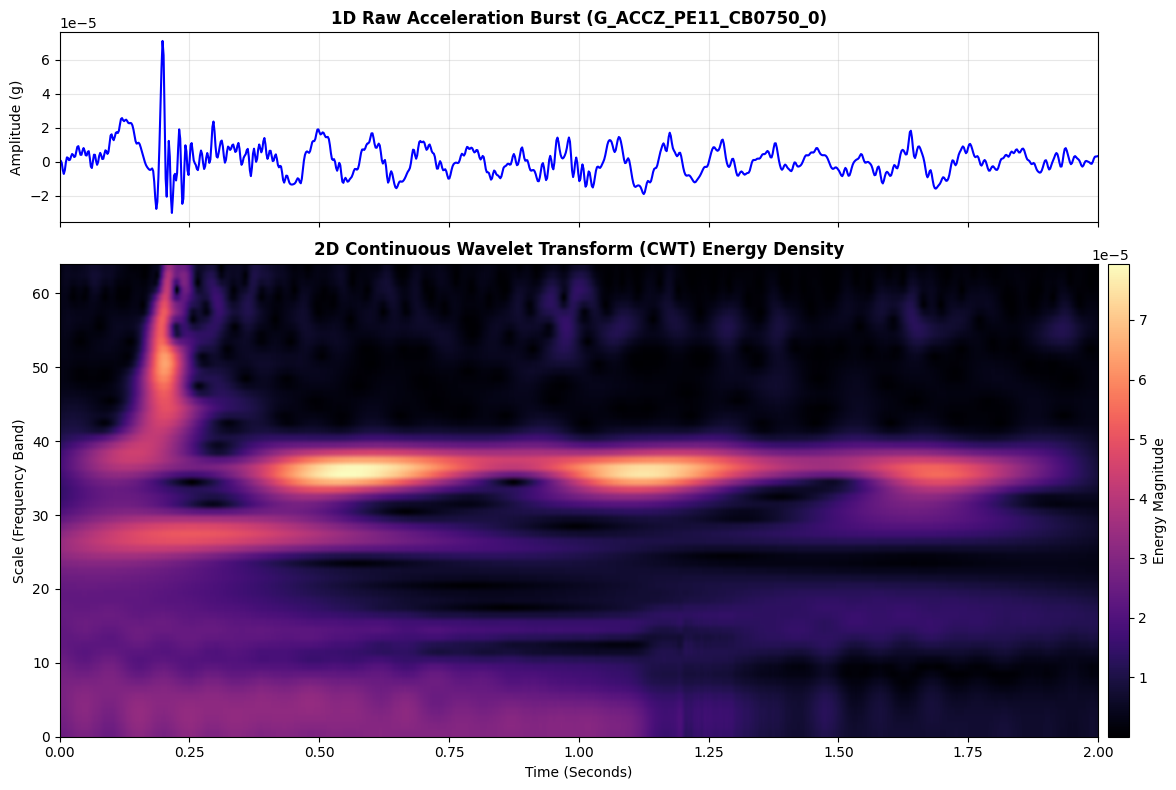

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import glob
import sys
import os

sys.path.append(os.path.abspath('.'))
from src.data.preprocess import compute_cwt

csv_files = glob.glob("/content/drive/MyDrive/spectra-cq-data/raw_csv/*.csv")
sample_csv = csv_files[0]
sensor_col = "G_ACCZ_PE11_CB0750_0"

df = pd.read_csv(sample_csv, usecols=[sensor_col]).dropna()
raw_signal = df[sensor_col].values

fs = 500
window_size = 2 * fs
signal_window = raw_signal[:window_size]
time_axis = np.linspace(0, 2, window_size)

spectrogram = compute_cwt(signal_window, fs=fs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2.5]})

# Top Plot: 1D Time-Domain Signal
ax1.plot(time_axis, signal_window, color='blue', linewidth=1.5)
ax1.set_title(f"1D Raw Acceleration Burst ({sensor_col})", fontsize=12, fontweight='bold')
ax1.set_ylabel("Amplitude (g)")
ax1.grid(True, alpha=0.3)

# Force ax1 to reserve the exact same right-side margin as ax2's colorbar
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="2%", pad=0.1)
cax1.axis('off')

# Bottom Plot: 2D Spectrogram
im = ax2.imshow(spectrogram, aspect='auto', cmap='magma', origin='lower', extent=[0, 2, 0, 64])
ax2.set_title("2D Continuous Wavelet Transform (CWT) Energy Density Spectrogram", fontsize=12, fontweight='bold')
ax2.set_ylabel("Scale (Frequency Band)")
ax2.set_xlabel("Time (Seconds)")

# Append the colorbar cleanly without squishing the main axis
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
fig.colorbar(im, cax=cax2, label='Energy Magnitude')

plt.tight_layout()
plt.show()

##### **NOTE:**
The visual "blurriness" of the 2D CWT spectrogram is not a loss of data quality.

It is a mathematically deliberate feature governed by the **Heisenberg-Gabor Limit** (the uncertainty principle of signal processing):
$$\Delta t \Delta f \ge \frac{1}{4\pi}$$

This principle states that a signal cannot have infinite resolution in both time and frequency simultaneously.

By setting our Morlet wavelet parameter to $\omega_0 = 6.0$, we explicitly establish a symmetric "sweet spot" that balances:
* time-domain precision (when the shock occurred)
* frequency-domain precision (what structural resonance was triggered).

Furthermore, this continuous, smoothed energy density acts as a natural low-pass filter. It prevents our subsequent Convolutional Autoencoder from overfitting to high-frequency stochastic environmental noise $\leftarrow$ forces the latent bottleneck to strictly memorize the macroscopic resonant frequencies of the bridge structure.

#### **2. Execute the Bulk Preprocessing Pipeline**
With the math verified, we iterate through all raw CSVs, extract the Z-axis telemetry, apply the CWT $\rightarrow$ then save the compressed `.npy` matrices to the drive for PyTorch ingestion.

In [ ]:
!python src/data/preprocess.py \
    --input_dir "/content/drive/MyDrive/spectra-cq-data/raw_csv" \
    --output_dir "/content/drive/MyDrive/spectra-cq-data/processed_spectrograms_PE11" \
    --sensor "G_ACCZ_PE11_CB0750_0" \
    --window 2

2026-06-17 07:13:45,534 - INFO - Initialized processing pipeline for 526 files. Target node: G_ACCZ_PE11_CB0750_0
Applying CWT via Morlet Kernel:   0% 0/526 [00:00<?, ?it/s]/content/SPECTRA-CQ/src/data/preprocess.py:39: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  coefficients = signal.cwt(signal_window, signal.morlet2, widths=scales, w=w)
Applying CWT via Morlet Kernel:   0% 1/526 [00:01<12:56,  1.48s/it]/content/SPECTRA-CQ/src/data/preprocess.py:39: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  coefficients = signal.cwt(signal_window, signal.morlet2, widths=scales, w=w)
Applying CWT via Morlet Kernel:   0% 2/526 [00:03<16:21,  1.87s/it]/content/SPECTRA-CQ/src/data/preprocess.py:39: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend u